# Photoswitching fingerprint fitting procedure

## 4 Fluorophore system

In [1]:
import os
import sys
import glob

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.distributions as dist
import src.figure as fi
import src.routines as ro
import src.fitting as fit

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings

def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

### Reading the data
The data is from a simulation which incooperates the ON to OFF energy transfer but no other, at different distances

In [2]:
distances = [3, 5, 6, 8]
identifiers = [f"{distance}nm" for distance in distances]
bleaching_times_all = []
fingerprints_all = []

for _ in identifiers:
    fingerprints_all.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
folder_path = r"C:\Users\vie43sq\Desktop\Simulations\simulation_data\bleaching_fitting\4 fluorophores"
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        bleaching_times_all.append(np.load(file))
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                fingerprints_all[identifiers.index(id)] += pd.read_parquet(file).sum(axis=1)
                break

for i, fingerprint in enumerate(fingerprints_all):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_all[i] = fingerprint

### Fitting the delta bleaching times

WARNING for line:             df = fun(x1) - f0
 invalid value encountered in subtract 


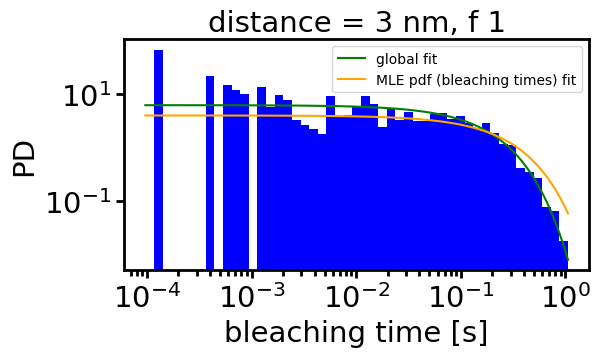

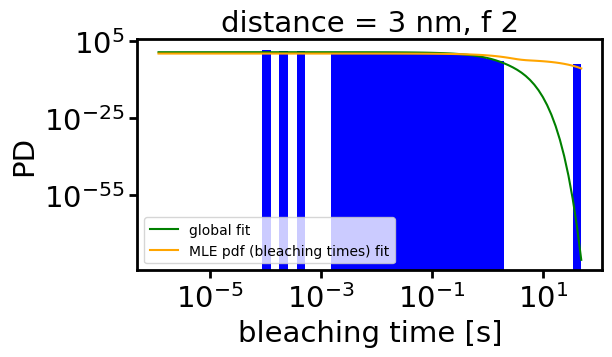

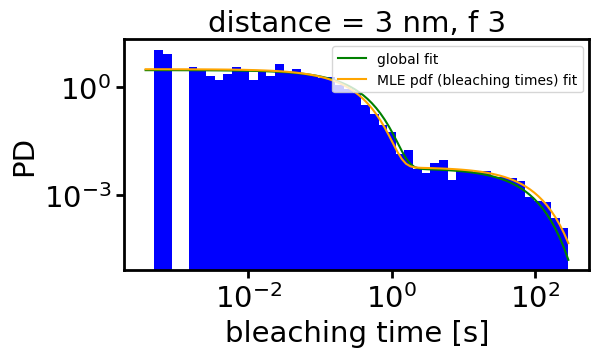

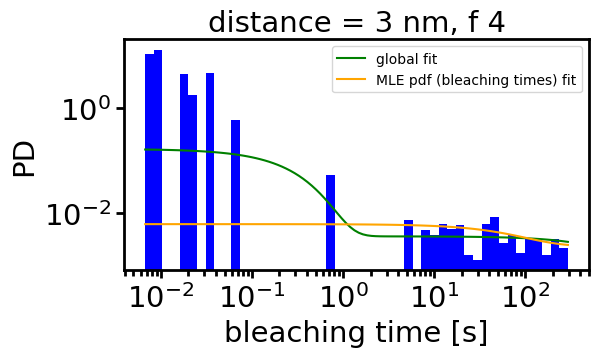

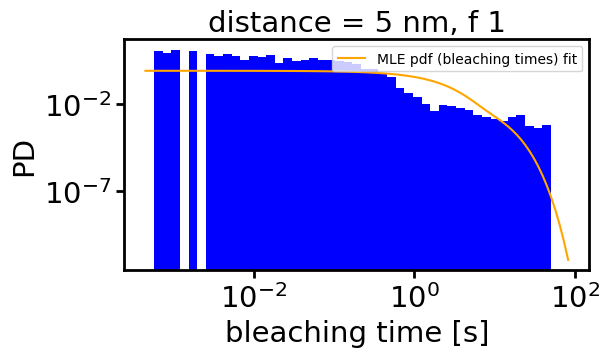

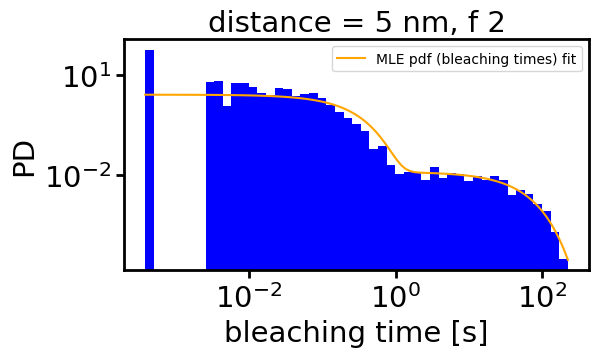

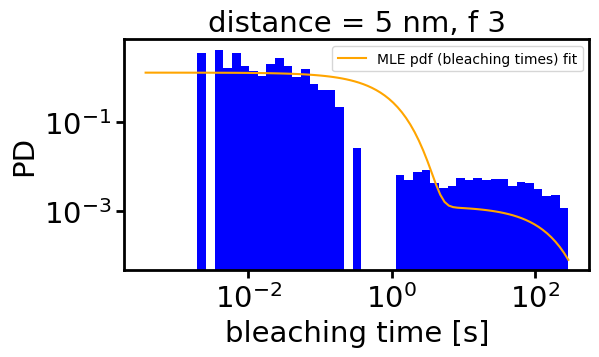

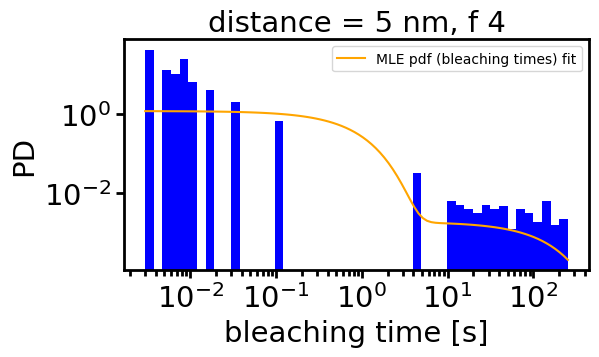

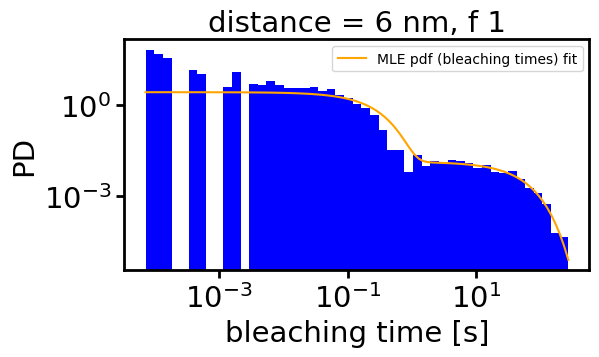

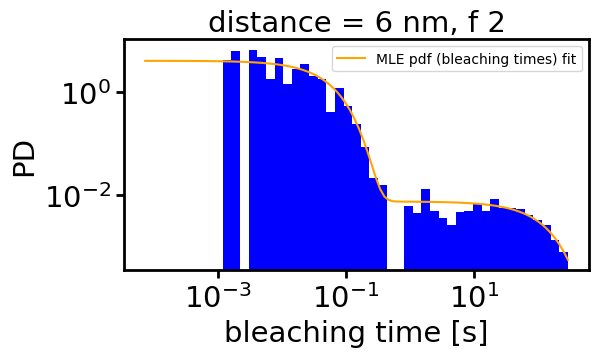

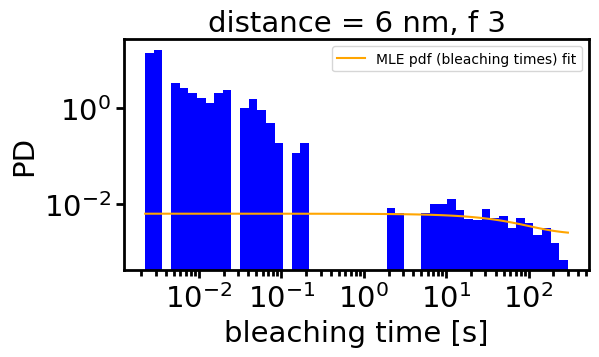

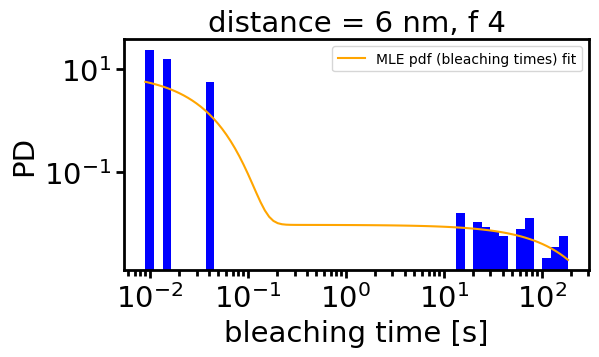

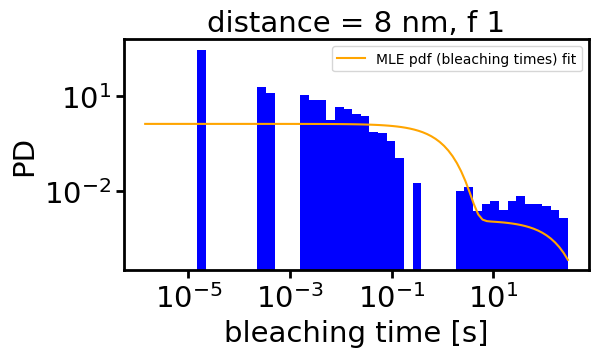

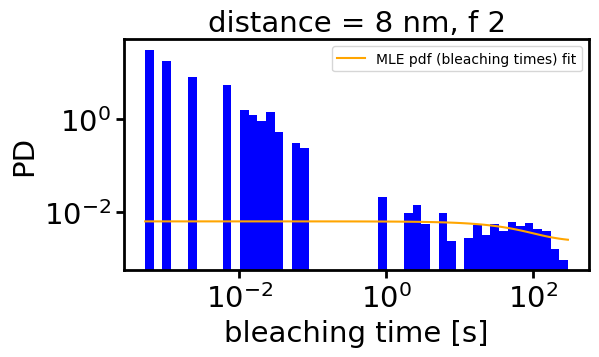

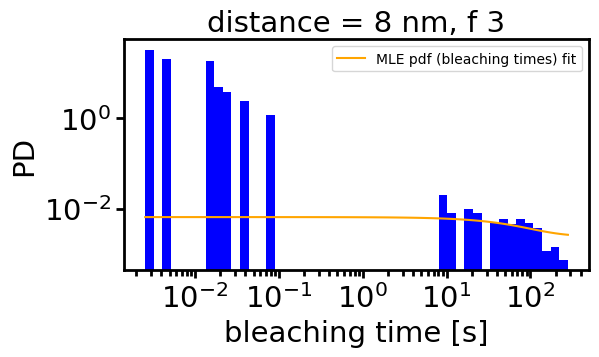

In [81]:
parameters_pdf_fit_all = []
for i, (bleaching_times, fingerprint, param_gl) in enumerate(zip(bleaching_times_all, fingerprints_all, parameters_ps_fingerprint_cdf_fit_4f_all)):
    parameters_pdf_fit, delta_bleaching_times = ro.get_global_bleaching_rates(bleaching_times)
    parameters_pdf_fit_all.append(parameters_pdf_fit)
    for j, (delta_bleaching_times_f, param_pdf) in enumerate(zip(delta_bleaching_times, parameters_pdf_fit)):
        x = np.logspace(np.log10(np.min(delta_bleaching_times_f)), np.log10(np.max(delta_bleaching_times_f)), 100)
        #x2 = np.logspace(np.log10(np.min(delta_bleaching_times_f)), np.log10(10), 100)
        bins_delta = np.logspace(np.log10(np.min(delta_bleaching_times_f)), np.log10(np.max(delta_bleaching_times_f)), 50)
        if delta_bleaching_times_f.size > 1:
            ax_delta = fi.universal_figure(type_='hist', bins=bins_delta, data=delta_bleaching_times_f, density=True)
            if i == 0:
                fi.universal_figure(data=[x, dist.two_expon_mixture_pdf(x, lambda1=result.x[j+0], lambda2=result.x[j+4], p=result.x[j+8])],
                                    color='green', label='global fit', axes=ax_delta)
            fi.universal_figure(data=[x, dist.two_expon_mixture_pdf(x, lambda1=param_pdf[0], lambda2=param_pdf[1], p=param_pdf[2])], 
                                color='orange', axes=ax_delta, label='MLE pdf (bleaching times) fit',
                                legend=True, xscale='log', yscale='log', xlabel='bleaching time [s]', ylabel='PD',
                                title=f'distance = {distances[i]} nm, f {j+1}')

### Approximation limits
The 2-exponential components approximation assumes two things: that there are only 2 components, and that they are exponentially distributed.
In the beginning, a *4-fluorophore* system has 4 fluorophores in their ON state. In contrast to a *1-fluorophore* system, this creates a **bias** not only because of the first ON state, but also the increased chance of a fluorophore entering the OFF state to be rescued due to the other 3 fluorophores still being in the ON state. Since there are so many possible energy transfer donors available, there is a high chance for the first fluorophore to bleach within this biased timeframe. \
Now that there are only 3 fluorophores left, if one enters the OFF state, the chance of being rescued before the other two entered the OFF state as well is smaller. The rescue chain may go on for a while, but eventuelly, all of them occupy the OFF state simultaneously (if the second bleaching event did not happen). Hence, there will be a (relatively) large time gap until the next bleaching event. At one point, one of the fluorophores will enter the ON state and has the ability to rescue the OFF state of one of the other two fluorophores. If a rescue happens, there is a even higher chance of rescueing the third. Now, the rescue chain may start again and there is a high chance of one of the fluorophores to bleach. Hence, the **non-biased** component may mainly be dictated by the *first OFF period (not OFF state) lifetime* of a 3 fluorophore system. \
Now there are only 2 fluorophores left. The chance of an ON state rescuing the other OFF state is much smaller, meaning rescuing chains being less likely. However, they can still happen. This is dictated mainly by the *OFF period lifetime of a 2-fluorophore system*. Times a factor that accounts for the higher rate due to rescue?

# k-fluorophore fits

In [3]:
x = np.linspace(0, 300, 300001)

Note: differential evolution is not *guaranteed* to succeed in finding the global minimum. Parameters like popsize and maxiter are crucial to achieve the correct outcome. Especially for many parameters, as in the 4-fluorophore scenario, maxiter may need to be increased. 

#### 1 Fluorophore fits

In [26]:
parameters_ps_fingerprint_cdf_fit_1f_all = []
for fingerprint in fingerprints_all:
    y = fingerprint.values
    result = fit.ps_fingerprint_cdf_fit_1f(x, y, maxiter=1000, popsize=50, disp=False)
    parameters_ps_fingerprint_cdf_fit_1f_all.append(result.x)

WARNING for line:                 self.H.update(self.x - self.x_prev, self.g - self.g_prev)
 delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations. 
WARNING for line:                 self.H.update(self.x - self.x_prev, self.g - self.g_prev)
 delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations. 
WARNING for line:                 self.H.update(self.x - self.x_prev, self.g - self.g_prev)
 delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations. 
WARNING for line:                 self.H.update(self.x - self.x_prev, self.g - self.g_prev)
 delta_grad == 0.0. Check 

#### 2 Fluorophore fits

In [31]:
parameters_ps_fingerprint_cdf_fit_2f_all = []
for fingerprint in fingerprints_all:
    y = fingerprint.values
    result = fit.ps_fingerprint_cdf_fit_2f(x, y, maxiter=1000, popsize=50, disp=False)
    parameters_ps_fingerprint_cdf_fit_2f_all.append(result.x)

WARNING for line:                 self.H.update(self.x - self.x_prev, self.g - self.g_prev)
 delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations. 
WARNING for line:                 self.H.update(self.x - self.x_prev, self.g - self.g_prev)
 delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations. 


#### 3 Fluorophore fits

In [32]:
parameters_ps_fingerprint_cdf_fit_3f_all = []
for fingerprint in fingerprints_all:
    y = fingerprint.values
    result = fit.ps_fingerprint_cdf_fit_3f(x, y, maxiter=1000, popsize=50, disp=False)
    parameters_ps_fingerprint_cdf_fit_3f_all.append(result.x)

#### 4 Fluorophore fits

In [5]:
result.x

array([4.12267770e+02, 3.43469045e+02, 1.26279088e+02, 6.15179182e+01,
       7.42791103e+00, 7.42682437e+00, 1.26348984e+00, 1.67122416e-03,
       3.52200045e-03, 2.37440790e-03, 1.23642945e-03, 1.17611483e-04])

In [12]:
result

             message: Optimization terminated successfully.
             success: True
                 fun: 0.7816663694667878
                   x: [ 6.319e+00  5.563e+00  4.100e+00  3.853e+00
                        4.686e+00  3.055e+00  2.037e-02  8.205e-04
                        9.789e-01  8.862e-01  7.641e-01  8.295e-03]
                 nit: 521
                nfev: 69116
          population: [[ 7.593e+00  7.354e+00 ...  7.459e-01  6.722e-01]
                       [ 8.434e+00  7.689e+00 ...  7.338e-01  6.750e-01]
                       ...
                       [ 7.937e+00  7.448e+00 ...  7.418e-01  6.989e-01]
                       [ 7.546e+00  7.352e+00 ...  7.421e-01  7.065e-01]]
 population_energies: [ 7.817e-01  5.392e+00 ...  5.354e+00  5.364e+00]
              constr: [array([ 0.000e+00,  0.000e+00, ...,  0.000e+00,
                              0.000e+00], shape=(13,))]
    constr_violation: 0.0
               maxcv: 0.0
                 jac: [array([[ 1.000e+00, -1

In [13]:
rng = np.random.default_rng(12345)
y = fingerprints_all[0].values
solutions = []
goodness_fit = []
for i in range(10):
    result = fit.ps_fingerprint_cdf_fit_4f(x, y, maxiter=2000, popsize=50, disp=False, rng=rng)
    solutions.append(result.x)
    goodness_fit.append(result.fun)

KeyboardInterrupt: 

In [11]:
result.x

array([6.31904298e+00, 5.56310395e+00, 4.10018130e+00, 3.85268797e+00,
       4.68564931e+00, 3.05453600e+00, 2.03715496e-02, 8.20526583e-04,
       9.78855277e-01, 8.86174405e-01, 7.64115774e-01, 8.29548618e-03])

In [ ]:
parameters_ps_fingerprint_cdf_fit_4f_all = []
for fingerprint in fingerprints_all:
    y = fingerprint.values
    result = fit.ps_fingerprint_cdf_fit_4f(x, y, maxiter=2000, popsize=150, disp=True, workers=-1)
    parameters_ps_fingerprint_cdf_fit_4f_all.append(result.x)

WARNING for line:     with DifferentialEvolutionSolver(func, bounds, args=args,
 differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred' 


differential_evolution step 1: f(x)= inf
differential_evolution step 2: f(x)= inf
differential_evolution step 3: f(x)= inf
differential_evolution step 4: f(x)= inf
differential_evolution step 5: f(x)= inf
differential_evolution step 6: f(x)= inf
differential_evolution step 7: f(x)= 1459.1718901372496
differential_evolution step 8: f(x)= 1459.1718901372496
differential_evolution step 9: f(x)= 1456.7629010149333
differential_evolution step 10: f(x)= 1456.7629010149333
differential_evolution step 11: f(x)= 1451.7551062791836
differential_evolution step 12: f(x)= 1451.7551062791836
differential_evolution step 13: f(x)= 1451.7551062791836
differential_evolution step 14: f(x)= 1451.7551062791836
differential_evolution step 15: f(x)= 1293.514513090272
differential_evolution step 16: f(x)= 1293.514513090272
differential_evolution step 17: f(x)= 1293.514513090272
differential_evolution step 18: f(x)= 1293.514513090272
differential_evolution step 19: f(x)= 1293.514513090272
differential_evolutio

KeyboardInterrupt: 

In [91]:
# save as file
directory = r"C:\Users\vie43sq\Desktop\Simulations\fitting_data\4_fluo_k_fluo_fingerprint_fits"
np.save(os.path.join(directory, '1f.npy'), parameters_ps_fingerprint_cdf_fit_1f_all)
np.save(os.path.join(directory, '2f.npy'), parameters_ps_fingerprint_cdf_fit_2f_all)
np.save(os.path.join(directory, '3f.npy'), parameters_ps_fingerprint_cdf_fit_3f_all)
np.save(os.path.join(directory, '4f.npy'), parameters_ps_fingerprint_cdf_fit_4f_all)

### Fit evaluation

In [97]:
parameters_ps_fingerprint_cdf_fit_4f_all

array([[7.91370822e+00, 6.98643623e+00, 6.98225989e+00, 1.33784374e+00,
        5.96812782e+00, 5.73667874e+00, 5.73050950e+00, 8.31993323e-03,
        7.65477812e-01, 7.63678133e-01, 7.62144480e-01, 7.60277164e-01],
       [4.59659552e+02, 3.43557567e+02, 3.02787808e+02, 1.99897107e+02,
        7.58473611e+00, 4.83851375e+00, 2.42526315e-02, 4.24202699e-03,
        3.03365908e-03, 2.02537129e-03, 1.01695988e-03, 8.47978228e-06],
       [4.56263124e+02, 3.74357461e+02, 2.75795033e+02, 1.04318299e+02,
        5.21707863e+00, 2.70276837e-02, 1.04419752e-02, 6.96538201e-03,
        8.00424972e-02, 2.00202026e-03, 1.00134609e-03, 6.73042030e-07],
       [3.15653219e+01, 2.28118287e+01, 1.70503847e+01, 5.83504080e+00,
        6.64904922e-03, 4.08588371e-03, 3.08588282e-03, 2.08588113e-03,
        2.37532849e-01, 2.03307050e-03, 1.02581664e-03, 1.16106514e-05]])

In [92]:
# load from file
parameters_ps_fingerprint_cdf_fit_1f_all = np.load(os.path.join(directory, '1f.npy'))
parameters_ps_fingerprint_cdf_fit_2f_all = np.load(os.path.join(directory, '2f.npy'))
parameters_ps_fingerprint_cdf_fit_3f_all = np.load(os.path.join(directory, '3f.npy'))
parameters_ps_fingerprint_cdf_fit_4f_all = np.load(os.path.join(directory, '4f.npy'))                                

In [93]:
from sklearn.metrics import r2_score

In [95]:
r_2_scores = []
for (fingerprint, param1f, param2f, param3f, param4f) in zip(fingerprints_all, 
                                                    parameters_ps_fingerprint_cdf_fit_1f_all, 
                                                    parameters_ps_fingerprint_cdf_fit_2f_all, 
                                                    parameters_ps_fingerprint_cdf_fit_3f_all,
                                                    parameters_ps_fingerprint_cdf_fit_4f_all):
    y = fingerprint.values
    x = np.linspace(0, 300, 300001)
    r2_score_1f = r2_score(y, dist.ps_fingerprint_cdf_1f(x, *param1f, domain=(x[0], x[-1])))
    r2_score_2f = r2_score(y, dist.ps_fingerprint_cdf_2f(x, *param2f, domain=(x[0], x[-1])))
    r2_score_3f = r2_score(y, dist.ps_fingerprint_cdf_3f(x, *param3f, domain=(x[0], x[-1])))
    r2_score_4f = r2_score(y, dist.ps_fingerprint_cdf_4f(x, *param4f, domain=(x[0], x[-1])))
    r_2_scores.append([r2_score_1f, r2_score_2f, r2_score_3f, r2_score_4f])

array([[<Axes: ylabel='r2 score'>]], dtype=object)

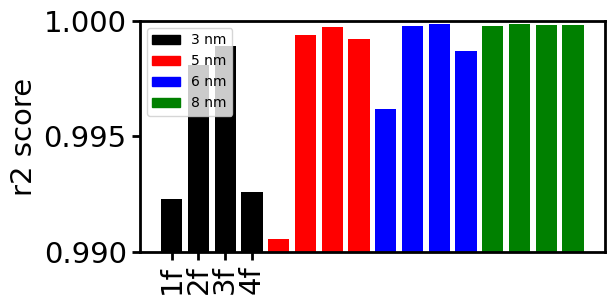

In [96]:
import matplotlib as mpl
colors = ['black'] * 4 + ['red'] * 4 + ['blue'] * 4 + ['green'] * 4
patches = [mpl.patches.Patch(color='black', label='3 nm'),
           mpl.patches.Patch(color='red', label='5 nm'),
           mpl.patches.Patch(color='blue', label='6 nm'),
           mpl.patches.Patch(color='green', label='8 nm')]
xticklabels = ['1f', '2f', '3f', '4f']
fi.universal_figure(type_='bar', data=[np.arange(0, 16, 1), np.array(r_2_scores).flatten()],
                    ylim=[0.99, 1], color=colors, ylabel='r2 score', xlabel='',
                    legendhandles=patches, legend=True, xticks=np.arange(0, 4, 1), xticklabels=dict(labels=xticklabels, rotation=90))

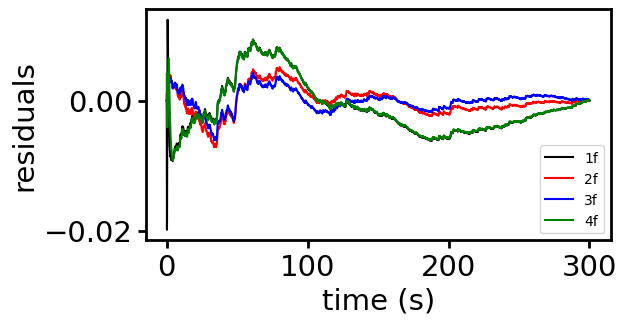

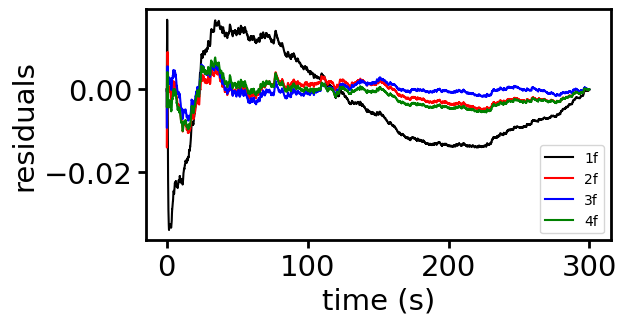

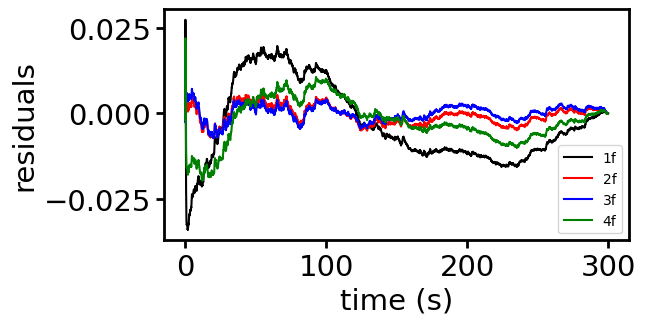

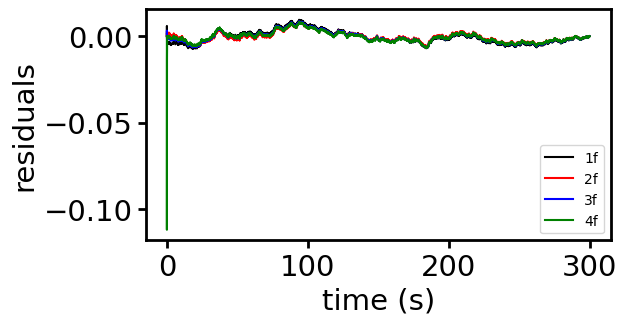

In [62]:
for fingerprint, parameters1, parameters2, parameters3, parameters4 in zip(fingerprints_all, 
                                                                           parameters_ps_fingerprint_cdf_fit_1f_all,
                                                                           parameters_ps_fingerprint_cdf_fit_2f_all,
                                                                           parameters_ps_fingerprint_cdf_fit_3f_all,
                                                                           parameters_ps_fingerprint_cdf_fit_4f_all):
    x = np.linspace(0, 300, 300001)
    residual1 = fingerprint.values - dist.ps_fingerprint_cdf_1f(x, *parameters1)
    residual2 = fingerprint.values - dist.ps_fingerprint_cdf_2f(x, *parameters2)
    residual3 = fingerprint.values - dist.ps_fingerprint_cdf_3f(x, *parameters3)
    residual4 = fingerprint.values - dist.ps_fingerprint_cdf_4f(x, *parameters4)
    ax = fi.universal_figure(data=[x, residual1], label='1f', color='black')
    fi.universal_figure(data=[x, residual2], label='2f', color='red', axes=ax)
    fi.universal_figure(data=[x, residual3], label='3f', color='blue', axes=ax)
    fi.universal_figure(data=[x, residual4], label='4f', legend=True, xlabel='time (s)', 
                        ylabel='residuals', color='green', axes=ax)